# Data quality and portfolio EDA

The source tables, observation periods and main risk characteristics are reviewed before modelling.

In [1]:
from pathlib import Path
import json
import sqlite3
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score, brier_score_loss, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd().resolve()
if not (ROOT / "config").exists():
    ROOT = ROOT.parent
DB = ROOT / "database" / "ifrs9_ecl.sqlite3"

def query(sql):
    with sqlite3.connect(DB) as connection:
        return pd.read_sql_query(sql, connection)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.rcParams["figure.figsize"] = (9, 4)

In [2]:
query('''
select 'origination_mortgages' table_name, count(*) rows, count(distinct loan_id) loans from origination_mortgages
union all
select 'monthly_loan_performance', count(*), count(distinct loan_id) from monthly_loan_performance
union all
select 'reporting_date_portfolio', count(*), count(distinct loan_id) from reporting_date_portfolio
''')

,table_name,rows,loans
0,origination_mortgages,50000,50000
1,monthly_loan_performance,1037964,15000
2,reporting_date_portfolio,3471,3471


In [3]:
query('''
select min(period) first_month, max(period) last_month,
avg(current_actual_upb) average_upb, avg(current_dpd) average_dpd
from monthly_loan_performance
''')

,first_month,last_month,average_upb,average_dpd
0,2015-01-01,2026-03-01,"182,213.8819",1.8409


In [4]:
portfolio = query('''select classic_fico, original_dti, current_ltv,
current_actual_upb, current_dpd, loan_age from reporting_date_portfolio''')
portfolio.describe(percentiles=[.01,.10,.25,.50,.75,.90,.99]).T

,count,mean,std,min,1%,10%,25%,50%,75%,90%,99%,max
classic_fico,"3,471.0000",750.2541,49.4412,486.0000,620.4000,683.0000,718.0000,762.0000,790.0000,804.0000,818.0000,826.0000
original_dti,"3,086.0000",33.8027,9.3985,2.0000,12.0000,20.0000,27.0000,35.0000,41.0000,45.0000,50.0000,50.0000
current_ltv,"3,471.0000",27.7169,15.2940,1.0000,2.9530,9.0000,16.0000,27.0000,36.0000,46.0000,72.7171,134.1184
current_actual_upb,"3,471.0000","124,737.4739","89,079.5635",509.9300,"7,224.8890","33,256.5600","57,969.0000","103,192.5500","170,158.3400","249,602.6200","418,891.6700","649,917.1200"
current_dpd,"3,471.0000",1.8410,27.2354,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,30.0000,"1,020.0000"
loan_age,"3,471.0000",126.0815,10.9063,0.0000,51.7000,122.0000,124.0000,127.0000,130.0000,132.0000,133.0000,133.0000


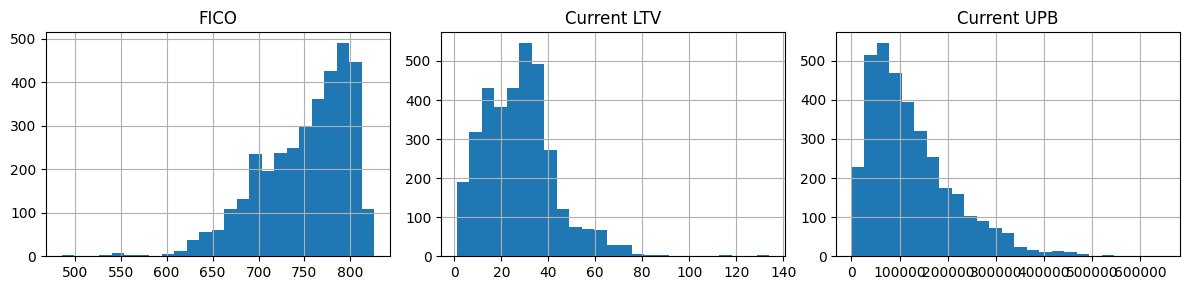

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
portfolio['classic_fico'].hist(bins=25, ax=axes[0]); axes[0].set_title('FICO')
portfolio['current_ltv'].clip(upper=150).hist(bins=25, ax=axes[1]); axes[1].set_title('Current LTV')
portfolio['current_actual_upb'].hist(bins=25, ax=axes[2]); axes[2].set_title('Current UPB')
plt.tight_layout()

Output: a checked modelling population with one loan identifier and ordered monthly observations.